## Khám phá dữ liệu (EDA) trước khi tiền xử lý

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

csv_file = "../data/raw/Online Retail.csv"
df = pd.read_csv(csv_file, encoding="utf-8-sig")

# Parse InvoiceDate ngay từ đầu; errors='coerce' để tránh crash nếu có ngày lỗi định dạng
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print(f"Kích thước dữ liệu gốc: {df.shape}")
df.head()

Kích thước dữ liệu gốc: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Ý NGHĨA CÁC CỘT
InvoiceNo: id hóa đơn

StockCode: id của món hàng

Description: Tên món hàng

Quantity: số lượng

Invoice Date: Ngày mua

UnitPrice: đơn giá

CustomerID: ID khách hàng

Country: Quốc gia của khách hàng


In [2]:
print("Thông tin tổng quan về dữ liệu:")
df.info()
print()
print("Thống kê mô tả các cột số:")
df.describe()

Thông tin tổng quan về dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB

Thống kê mô tả các cột số:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


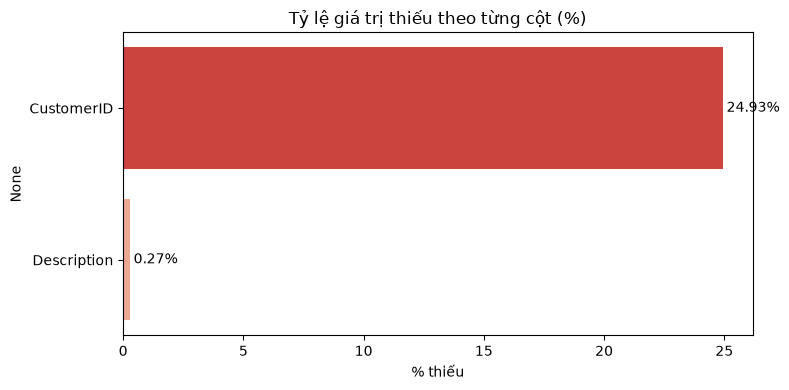

In [4]:
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index,
            palette='Reds_r', legend=False)
plt.title('Tỷ lệ giá trị thiếu theo từng cột (%)')
plt.xlabel('% thiếu')
for i, v in enumerate(missing_pct.values):
    plt.text(v, i, f' {v:.2f}%', va='center')
plt.tight_layout()
plt.show()

**Thiếu ID khách hàng -> k thể phân tích -> Phải xóa các dòng này \
Thiếu Description thì không sao vì nó thường mô tả tên sản phẩm thôi**


### Số dòng =0 hoặc âm

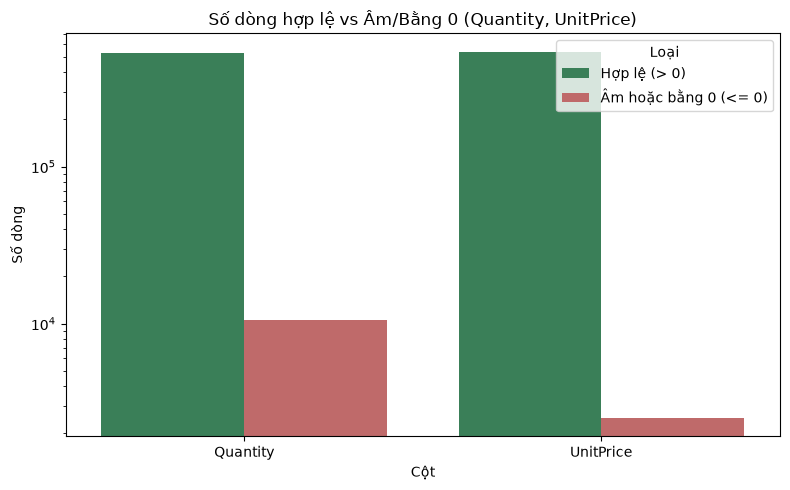

         Cột  Hợp lệ (> 0)  Âm hoặc bằng 0 (<= 0)
0   Quantity        531285                  10624
1  UnitPrice        539392                   2517


In [5]:
negative_stats = pd.DataFrame({
    'Cột': ['Quantity', 'UnitPrice'],
    'Hợp lệ (> 0)': [(df['Quantity'] > 0).sum(), (df['UnitPrice'] > 0).sum()],
    'Âm hoặc bằng 0 (<= 0)': [(df['Quantity'] <= 0).sum(), (df['UnitPrice'] <= 0).sum()]
})

negative_stats_melted = negative_stats.melt(id_vars='Cột', var_name='Loại', value_name='Số dòng')

plt.figure(figsize=(8, 5))
sns.barplot(data=negative_stats_melted, x='Cột', y='Số dòng', hue='Loại',
            palette=['seagreen', 'indianred'])
plt.title('Số dòng hợp lệ vs Âm/Bằng 0 (Quantity, UnitPrice)')
plt.yscale('log')  # dùng thang log vì số hợp lệ thường lớn hơn rất nhiều so với số lỗi
plt.tight_layout()
plt.show()

print(negative_stats)

**Có thể là do khuyến mãi hoặc là do lỗi nhập liệu -> Ta cũng cần xóa các dòng này**

In [6]:
# Xem 10 dòng có Quantity cực đoan nhất (cả 2 chiều dương/âm)
print("Quantity cực đoan:")
print(df.nlargest(10, 'Quantity')[['InvoiceNo','Description','Quantity','UnitPrice','CustomerID']])
print(df.nsmallest(10, 'Quantity')[['InvoiceNo','Description','Quantity','UnitPrice','CustomerID']])

print("\nUnitPrice cực đoan:")
print(df.nlargest(10, 'UnitPrice')[['InvoiceNo','Description','Quantity','UnitPrice','CustomerID']])

Quantity cực đoan:
       InvoiceNo                          Description  Quantity  UnitPrice  \
540421    581483          PAPER CRAFT , LITTLE BIRDIE     80995       2.08   
61619     541431       MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04   
502122    578841       ASSTD DESIGN 3D PAPER STICKERS     12540       0.00   
74614     542504                                  NaN      5568       0.00   
421632    573008    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800       0.21   
206121    554868                 SMALL POPCORN HOLDER      4300       0.72   
220843    556231                                    ?      4000       0.00   
97432     544612                EMPIRE DESIGN ROSETTE      3906       0.82   
270885    560599  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186       0.06   
52711     540815   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114       2.10   

        CustomerID  
540421     16446.0  
61619      12346.0  
502122     13256.0  
74614          NaN  
421632     12901.

**Quantity cao là khách sỉ \
Quantity âm là những dòng phí hay nợ gì đó ko phải giao dịch thật sự -> Cần xóa**

### SỐ LẦN MUA CỦA CÁC KHÁCH HÀNG

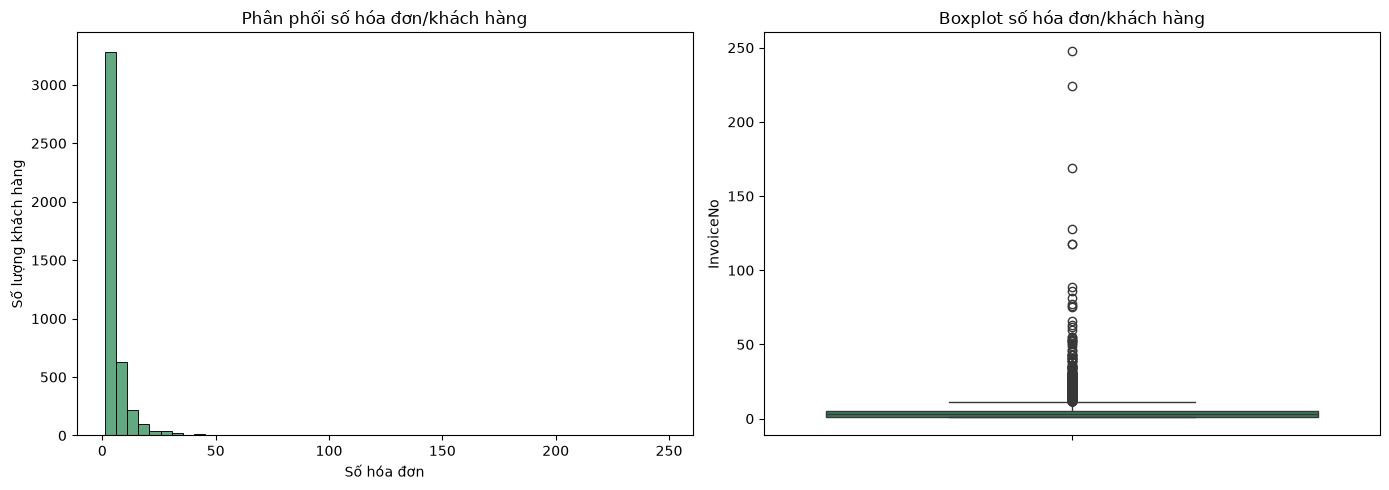

Thống kê mô tả số hóa đơn/khách hàng:
count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

Số khách hàng chỉ mua 1 lần: 1,313 (30.0%)


In [8]:
customer_txn = df.dropna(subset=['CustomerID']).groupby('CustomerID')['InvoiceNo'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(customer_txn, bins=50, ax=axes[0], color='seagreen')
axes[0].set_title('Phân phối số hóa đơn/khách hàng')
axes[0].set_xlabel('Số hóa đơn')
axes[0].set_ylabel('Số lượng khách hàng')

sns.boxplot(y=customer_txn, ax=axes[1], color='seagreen')
axes[1].set_title('Boxplot số hóa đơn/khách hàng')

plt.tight_layout()
plt.show()

print("Thống kê mô tả số hóa đơn/khách hàng:")
print(customer_txn.describe())
print(f"\nSố khách hàng chỉ mua 1 lần: {(customer_txn == 1).sum():,} ({(customer_txn == 1).mean()*100:.1f}%)")

**Các khách hàng với số lần mua cực khủng (trên 100 lần) sẽ là outlier -> cần có cách xử lý (xóa hẵn hoặc ép nó về 1 khoảng)**

### Top 10 quốc gia theo số lượng giao dịch

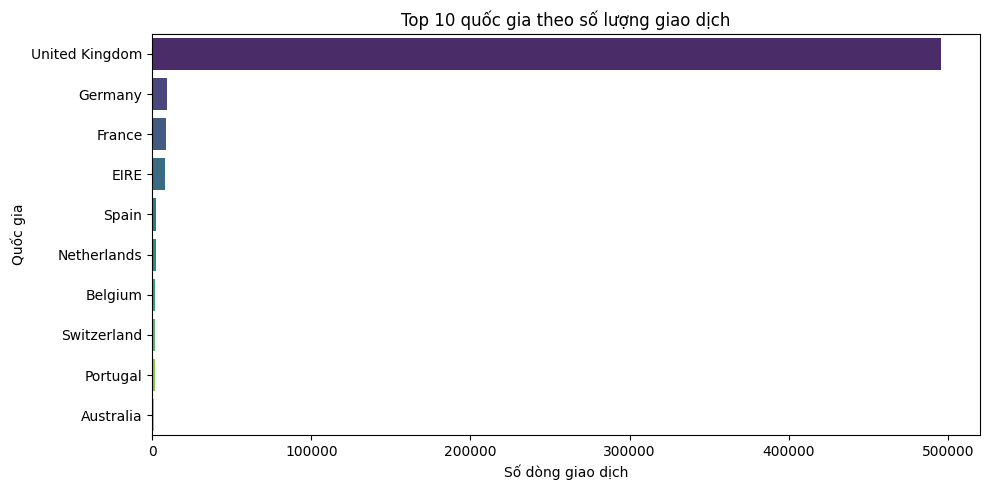

In [ ]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 quốc gia theo số lượng giao dịch')
plt.xlabel('Số dòng giao dịch')
plt.ylabel('Quốc gia')
plt.tight_layout()
plt.show()

### Xu hướng số lượng giao dịch theo thời gian

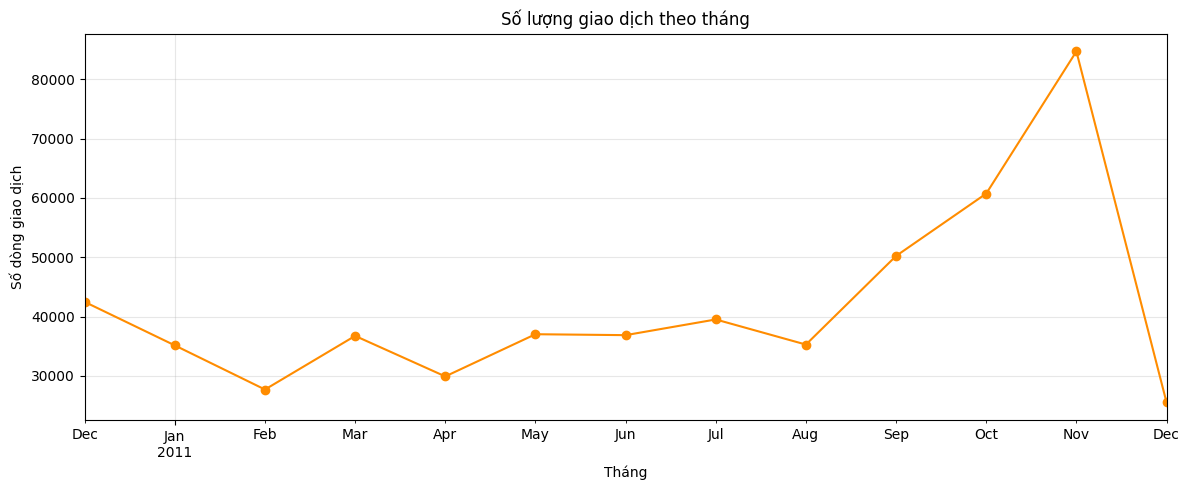

In [ ]:
df_time = df.dropna(subset=['InvoiceDate']).copy()
monthly_transactions = df_time.set_index('InvoiceDate').resample('ME').size()

plt.figure(figsize=(12, 5))
monthly_transactions.plot(marker='o', color='darkorange')
plt.title('Số lượng giao dịch theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số dòng giao dịch')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Top 10 sản phẩm bán chạy nhất theo tổng số lượng

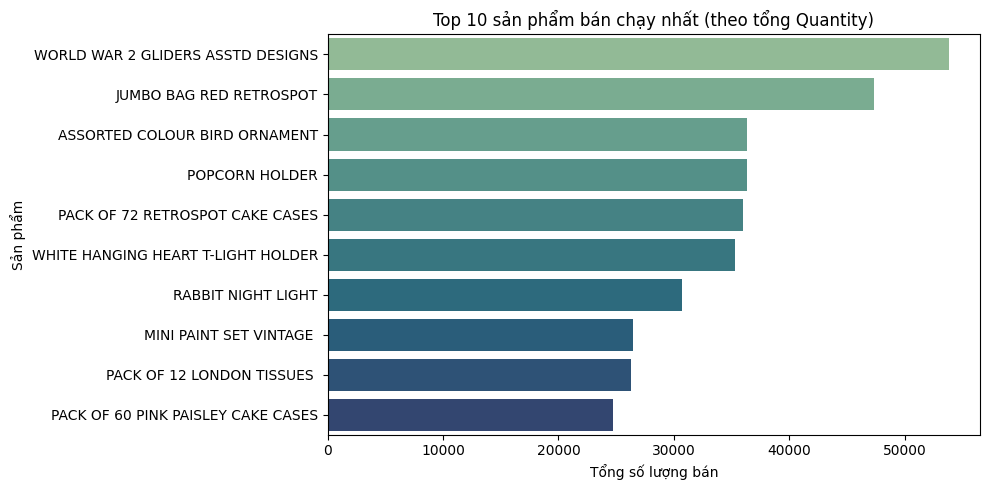

In [ ]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='crest', legend=False)
plt.title('Top 10 sản phẩm bán chạy nhất (theo tổng Quantity)')
plt.xlabel('Tổng số lượng bán')
plt.ylabel('Sản phẩm')
plt.tight_layout()
plt.show()

# Phân khúc khách hàng — Tiền xử lý dữ liệu RFM

**Pipeline:**

```
Raw Data
  -> Remove Quantity<=0
  -> Remove UnitPrice<=0
  -> Remove Null CustomerID
  -> Remove Duplicate
  -> TotalPrice (feature)
  -> RFM
  -> Remove Outlier
  -> Log Transform
  -> StandardScaler
  
```

## Bước 1: Remove Quantity <= 0

In [ ]:
before = df.shape[0]
df = df[df['Quantity'] > 0]
print(f"[Bước 1] Loại Quantity <= 0: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

[Bước 1] Loại Quantity <= 0: xóa 10,624 dòng -> còn 531,285 dòng


## Bước 2: Remove UnitPrice <= 0

In [ ]:
before = df.shape[0]
df = df[df['UnitPrice'] > 0]
print(f"[Bước 2] Loại UnitPrice <= 0: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

[Bước 2] Loại UnitPrice <= 0: xóa 1,181 dòng -> còn 530,104 dòng


## Bước 3: Remove Null CustomerID

In [ ]:
before = df.shape[0]
# Loại luôn cả InvoiceDate bị lỗi định dạng (NaT) cùng lúc vì cả 2 đều là trường bắt buộc cho RFM
df = df.dropna(subset=['CustomerID', 'InvoiceDate'])
print(f"[Bước 3] Loại CustomerID rỗng / InvoiceDate lỗi: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

df['CustomerID'] = df['CustomerID'].astype(int)

[Bước 3] Loại CustomerID rỗng / InvoiceDate lỗi: xóa 132,220 dòng -> còn 397,884 dòng


## Bước 4: Remove Duplicate

**Lưu ý quan trọng:** dedup được thực hiện ở đây, khi `StockCode`/`Description` **vẫn còn nguyên** trong dữ liệu (chưa bị drop). Nếu dedup sau khi đã mất 2 cột này, hai dòng khác **sản phẩm** nhưng trùng InvoiceNo/Quantity/UnitPrice/InvoiceDate sẽ bị nhầm là trùng lặp và bị xóa oan, làm sai lệch Frequency/Monetary.

In [ ]:
before = df.shape[0]
df = df.drop_duplicates()
print(f"[Bước 4] Loại dòng trùng lặp hoàn toàn: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

[Bước 4] Loại dòng trùng lặp hoàn toàn: xóa 5,192 dòng -> còn 392,692 dòng


## Bước 5: TotalPrice (feature)

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalPrice']].head()

,InvoiceNo,Quantity,UnitPrice,TotalPrice
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


## Bước 6: Tính RFM

In [ ]:
snapshot_date = df['InvoiceDate'].max()
print(f"Ngày mốc tính Recency: {snapshot_date}")

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print(f"Tổng số khách hàng: {rfm.shape[0]}")
rfm.describe()

Ngày mốc tính Recency: 2011-12-09 12:50:00
Tổng số khách hàng: 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,0.000000,1.000000,3.750000
25%,13813.250000,17.000000,1.000000,306.482500
50%,15299.500000,50.000000,2.000000,668.570000
75%,16778.750000,141.000000,5.000000,1660.597500
max,18287.000000,373.000000,209.000000,280206.020000


In [ ]:
# Lưu TOÀN BỘ RFM
# File này dùng ở train.ipynb để dự đoán cụm cho TẤT CẢ khách hàng
full_rfm_path = '../data/processed/customer_segmentation_full.csv'
os.makedirs(os.path.dirname(full_rfm_path), exist_ok=True)
rfm.to_csv(full_rfm_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu chỉ số RFM tại: {full_rfm_path}")

Đã lưu chỉ số RFM tại: ../data/processed/customer_segmentation_full.csv


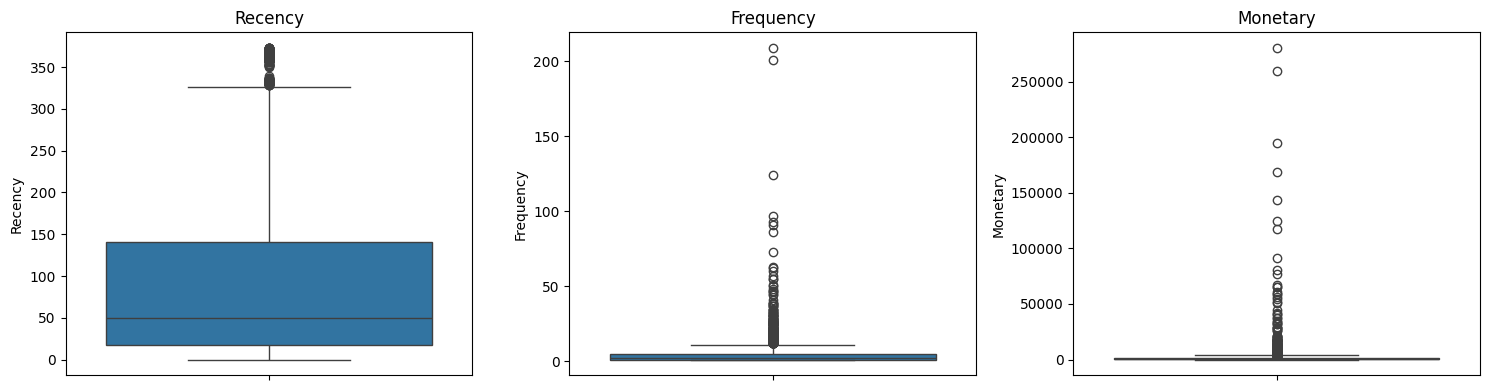

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm[col], ax=ax)
    ax.set_title(f'{col}')
plt.tight_layout()
plt.show()

## Bước 7: CLip Outlier



In [ ]:
# 1. Giới hạn (clip) outlier bằng phương pháp IQR - KHÔNG xóa khách hàng, chỉ kẹp giá trị cực đoan về biên
cols_to_clean = ['Recency', 'Frequency', 'Monetary']
rfm_cleaned = rfm.copy()

for col in cols_to_clean:
    Q1 = rfm_cleaned[col].quantile(0.25)
    Q3 = rfm_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    num_clipped = ((rfm_cleaned[col] < lower_bound) | (rfm_cleaned[col] > upper_bound)).sum()
    rfm_cleaned[col] = rfm_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
    print(f" -> Cột '{col}': đã kẹp {num_clipped:,} giá trị cực đoan về khoảng [{lower_bound:.2f}, {upper_bound:.2f}]")

print(f" -> Tổng số khách hàng (giữ nguyên, không xóa ai): {rfm_cleaned.shape[0]:,}")


 -> Cột 'Recency': đã kẹp 155 giá trị cực đoan về khoảng [-169.00, 327.00]
 -> Cột 'Frequency': đã kẹp 285 giá trị cực đoan về khoảng [-5.00, 11.00]
 -> Cột 'Monetary': đã kẹp 425 giá trị cực đoan về khoảng [-1724.69, 3691.77]
 -> Tổng số khách hàng (giữ nguyên, không xóa ai): 4,338


In [ ]:
# Lưu bảng RFM đơn vị gốc (đã clip)
processed_dir = "../data/processed"
os.makedirs(processed_dir, exist_ok=True)
raw_rfm_path = os.path.join(processed_dir, 'customer_segmentation.csv')
rfm_cleaned.to_csv(raw_rfm_path, index=False, encoding='utf-8-sig')
print(f"-> Đã lưu bảng RFM đã xử lý (đơn vị gốc) tại: {raw_rfm_path}")

-> Đã lưu bảng RFM đã xử lý (đơn vị gốc) tại: ../data/processed/customer_segmentation.csv


## Bước 8: Log Transform

Frequency và Monetary vẫn còn lệch phải sau khi loại outlier -> dùng `log1p` để đưa phân phối gần chuẩn hơn, giúp K-Means/Hierarchical (dựa trên khoảng cách Euclidean) hoạt động hiệu quả hơn.

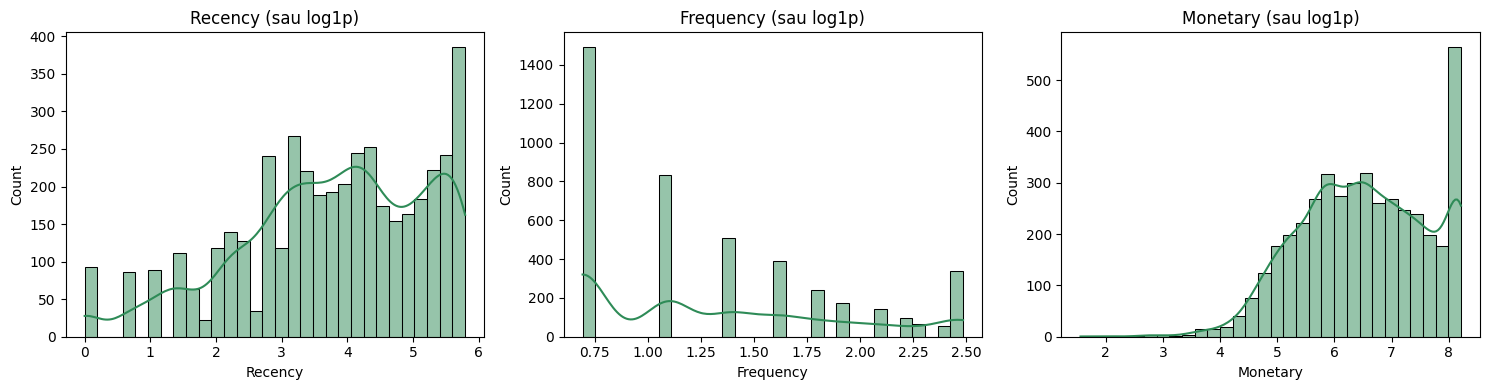

In [ ]:
# 2. Biến đổi phân phối Log-transform
rfm_log = rfm_cleaned[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Vẽ đồ thị sau khi log 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_log[col], bins=30, kde=True, ax=ax, color='seagreen')
    ax.set_title(f'{col} (sau log1p)')
plt.tight_layout()
plt.show()


## Bước 9: StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

#  Chuẩn hóa phân phối Z-score (StandardScaler)
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled_array, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.insert(0, 'CustomerID', rfm_cleaned['CustomerID'].values)

# Đóng gói và lưu trữ bộ chuẩn hóa 
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/rfm_scaler.pkl')
print("-> Đã đóng gói và lưu bộ chuẩn hóa tại: models/rfm_scaler.pkl")

# Lưu tập dữ liệu số đã xử lý hoàn chỉnh chuẩn bị đưa vào huấn luyện
scaled_data_path = os.path.join(processed_dir, 'customer_segmentation_scaled.csv')
rfm_scaled_df.to_csv(scaled_data_path, index=False, encoding="utf-8-sig")
print(f"-> Đã lưu tập dữ liệu chuẩn hóa tại: {scaled_data_path}")

-> Đã đóng gói và lưu bộ chuẩn hóa tại: models/rfm_scaler.pkl
-> Đã lưu tập dữ liệu chuẩn hóa tại: ../data/processed/customer_segmentation_scaled.csv


## Kết luận

Pipeline hoàn chỉnh: Raw Data -> lọc Quantity/UnitPrice/CustomerID -> Remove Duplicate -> TotalPrice -> RFM -> Clip Outlier (IQR) -> Log Transform -> StandardScaler

**Output:**
- `customer_segmentation.csv`: RFM đơn vị gốc dùng để diễn giải cụm (business profiling)
- `customer_segmentation_scaled.csv`: RFM đã log-transform + scale (3 chiều) — dùng để huấn luyện K-Means/Hierarchical/DBSCAN

